In [1]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import matplotlib.pyplot as plt
import requests

C:\Users\SRIKAR\Desktop\VS CODE\rag\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

C:\Users\SRIKAR\Desktop\VS CODE\rag\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SRIKAR\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 473/473 [00:00<00:00, 25418.72it/s]


In [7]:
image = Image.open(
    "../data/images/panda.webp"
).convert("RGB")

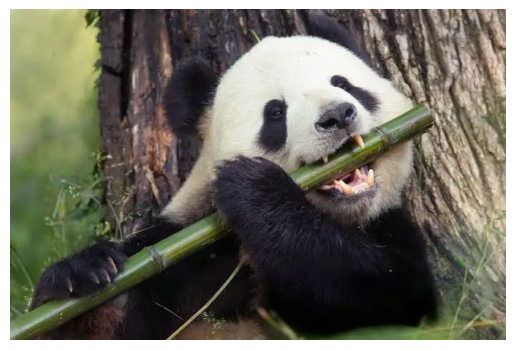

Generated Caption:
a panda eating bamboo sticks in a tree


In [8]:
inputs = processor(
    image,
    return_tensors="pt"
)

output = model.generate(
    **inputs
)

caption = processor.decode(
    output[0],
    skip_special_tokens=True
)

plt.imshow(image)
plt.axis("off")
plt.show()

print("Generated Caption:")
print(caption)

In [ ]:
import fitz
import os

pdf_path = "sample.pdf"
output_dir = "images"

os.makedirs(output_dir, exist_ok=True)

doc = fitz.open(pdf_path)

image_paths = []

for page_num in range(len(doc)):
    page = doc.load_page(page_num)

    for img_index, img in enumerate(page.get_images(full=True)):
        xref = img[0]
        pix = fitz.Pixmap(doc, xref)

        if pix.n < 5:
            image_path = os.path.join(
                output_dir,
                f"page_{page_num+1}_{img_index}.png"
            )
            pix.save(image_path)
        else:
            pix = fitz.Pixmap(fitz.csRGB, pix)
            image_path = os.path.join(
                output_dir,
                f"page_{page_num+1}_{img_index}.png"
            )
            pix.save(image_path)

        image_paths.append(image_path)

        pix = None

doc.close()

print(image_paths)

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

captions = []

for path in image_paths:

    image = Image.open(path).convert("RGB")

    inputs = processor(image, return_tensors="pt")

    output = model.generate(**inputs)

    caption = processor.decode(
        output[0],
        skip_special_tokens=True
    )

    captions.append({
        "image": path,
        "caption": caption
    })

print(captions)